# Tutorial 2 — Function Fitting with Inequality Constraints

This tutorial shows how to enforce **inequality constraints** with ENFORCE
using the **Fischer-Burmeister (FB) reformulation**.

**Problem:** learn the mapping

$$x \mapsto \sin(x) + \varepsilon, \quad x \in [0, 3\pi]$$

(where $\varepsilon$ is small noise) subject to the hard bounds

$$-1 \le y \le 1$$

---

## Outline
1. Generate noisy training data  
2. Define inequality functions  
3. Create a `FischerBurmeisterReformulation` wrapper  
4. Extend output labels with zero multiplier columns  
5. Scale data (handles zero-std FB columns automatically)  
6. Configure and build ENFORCE  
7. Train and evaluate  
8. Evaluate and check feasibility  

In [1]:
import sys, pathlib
_here = pathlib.Path.cwd()
_root = _here if (_here / "src").exists() else _here.parent
sys.path.insert(0, str(_root))

import numpy as np
import torch
import matplotlib.pyplot as plt

from src.enforce.config import ENFORCEConfig
from src.enforce.model import ENFORCE
from src.enforce.fb_inequality_constraints import FischerBurmeisterReformulation
from src.engines.train import Trainer, TrainingConfig
from src.engines.evaluate import Evaluator, EvaluationConfig
from src.data.data_utils import scale_data

np.random.seed(0)
torch.manual_seed(0)

## 1. Generate Training Data

We generate a noisy sine signal.  Some observed values intentionally exceed the
bounds `[-1, 1]` due to noise — the model should learn to **predict within
the bounds** even from such training data.

In [2]:
N_TRAIN, N_TEST = 300, 100
NOISE_STD, NOISE_BIAS = 0.25, 0.0

x_train = np.random.uniform(0.0, 3 * np.pi, N_TRAIN).reshape(-1, 1).astype(np.float32)
x_test  = np.linspace(0.0, 3 * np.pi, N_TEST).reshape(-1, 1).astype(np.float32)

rng = np.random.default_rng(0)
y_train = (np.sin(x_train) + NOISE_BIAS
           + rng.normal(0, NOISE_STD, x_train.shape)).astype(np.float32)
y_test  = np.sin(x_test).astype(np.float32)

print(f"y_train range: [{y_train.min():.3f}, {y_train.max():.3f}]")
print(f"Points outside [-1, 1]: {((y_train < -1) | (y_train > 1)).sum()} / {N_TRAIN}")

y_train range: [-1.383, 1.766]
Points outside [-1, 1]: 63 / 300


## 2. Define Inequality Functions

Each inequality `g_i(x, y) <= 0` is a Python callable:

```
g_i(x: Tensor[BS, NI], y: Tensor[BS, NO]) -> Tensor[BS]  (unscaled)
```

To enforce $-1 \le y \le 1$ we write two inequalities:

- $g_{\text{upper}}(x, y) = y_1 - 1 \le 0$
- $g_{\text{lower}}(x, y) = -y_1 - 1 \le 0$

In [3]:
def g_upper(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    """y <= 1  →  g = y - 1 <= 0"""
    return y[:, 0] - 1.0

def g_lower(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    """-y <= 1  →  g = -y - 1 <= 0"""
    return -y[:, 0] - 1.0

## 3. Create the Fischer-Burmeister Wrapper

`FischerBurmeisterReformulation` takes your inequality callables and produces an
equality residual suitable for ENFORCE.

**Extended-output convention:**  
The network predicts only the **original** `NO = n_original_outputs` outputs.
ENFORCE automatically appends `n_ineq` zero columns (the FB dual variables λ)
during `forward()`.  The constraint function operates on the full extended
vector `[y, λ₁, …, λₘ]`.

In [4]:
fb = FischerBurmeisterReformulation(
    n_original_outputs=1,
    inequalities=[g_upper, g_lower],
)

print(f"Original outputs  (fb.no):    {fb.no}")
print(f"Number of ineqs   (fb.n_ineq):{fb.n_ineq}")
print(f"Extended space:               {fb.no + fb.n_ineq}  (1 y + 2 λ)")

Original outputs  (fb.no):    1
Number of ineqs   (fb.n_ineq):2
Extended space:               3  (1 y + 2 λ)


## 4. Extend Output Labels with Zero Multiplier Columns

At feasible training points KKT complementarity forces `λ_i = 0`, so we
simply append zero columns.  `fb.extend_outputs()` does this for a numpy
array.

In [5]:
y_train_ext = fb.extend_outputs(y_train)  # [N_TRAIN, 1+2] = [N_TRAIN, 3]
y_test_ext  = fb.extend_outputs(y_test)

print(f"y_train_ext shape: {y_train_ext.shape}  (original y + 2 zero λ columns)")

y_train_ext shape: (300, 3)  (original y + 2 zero λ columns)


## 5. Scale Data

`scale_data` uses **per-column** z-score normalisation.  Lambda columns that
are always zero in training data (std ≈ 0) are automatically assigned
`std = 1.0` (a safe std) so they are left un-normalised.

In [6]:
x_tr_s, y_tr_s, x_te_s, y_te_s, sp = scale_data(
    x_train, y_train_ext, x_test, y_test_ext
)

x_tr_t = torch.tensor(x_tr_s, dtype=torch.float32)
y_tr_t = torch.tensor(y_tr_s, dtype=torch.float32)
x_te_t = torch.tensor(x_te_s, dtype=torch.float32)
y_te_t = torch.tensor(y_te_s, dtype=torch.float32)

# scaling_output covers the FULL extended space [y, λ1, λ2]
scaling_input  = (
    torch.tensor(sp["input_mean"],  dtype=torch.float32),
    torch.tensor(sp["input_std"],   dtype=torch.float32),
)
scaling_output = (
    torch.tensor(sp["output_mean"], dtype=torch.float32),
    torch.tensor(sp["output_std"],  dtype=torch.float32),
)

## 6. Configure and Build ENFORCE

When passing `fb` to `ENFORCE`:
- `output_neurons` in `ENFORCEConfig` = `fb.no` (original outputs only; no λ neurons)
- `c = fb` (the FB wrapper is its own constraint callable)
- `fb = fb` (tells `ENFORCE` to append λ columns in `forward()` and track the extended space)
- Set `ada_np_auto_activation=False` for inequality problems: we always project to enforce feasibility

> `model.no` = `fb.no + fb.n_ineq` (the full extended projection space).  
> `model.output_layer.out_features` = `fb.no` (the network only predicts original outputs).

In [7]:
cfg = ENFORCEConfig(
    input_neurons=1,
    hidden_neurons=64,
    output_neurons=fb.no,   # = 1  (y only; λ appended in forward)
    hidden_layers=1,
    training_tolerance=1e-4,
    inference_tolerance=1e-4,
    max_it=100,
    epoch_start_hard_constrained=0,
    ada_np_auto_activation=False,  # always project — enforce bounds unconditionally
    supervised=True,
    weight_loss_displacement=0.5,
)

model_enforce = ENFORCE(
    scaling_input=scaling_input,
    scaling_output=scaling_output,
    c=fb,          # FB wrapper acts as the constraint callable
    fb=fb,         # tells ENFORCE to extend the output space
    config=cfg,
    constrained=True,
    weighting_option=1,
)

# MLP baseline (no projection)
model_mlp = ENFORCE(
    scaling_input=scaling_input,
    scaling_output=scaling_output,
    c=fb,
    fb=fb,
    config=cfg,
    constrained=False,
)

print(f"Network output layer size: {model_enforce.output_layer.out_features}  (= fb.no = {fb.no})")
print(f"Full extended output size: {model_enforce.no}  (= fb.no + fb.n_ineq = {fb.no + fb.n_ineq})")

Network output layer size: 1  (= fb.no = 1)
Full extended output size: 3  (= fb.no + fb.n_ineq = 3)


## 7. Train

In [8]:
train_cfg = TrainingConfig(
    batch_size=64,
    epochs=500,
    learning_rate=1e-3,
    random_seed=0,
    # Pass inequality callables so the trainer can compute soft penalties
    # for the MLP baseline (optional; comment out if not needed)
    n_original_outputs=fb.no,
)

print("Training ENFORCE...")
model_enforce = Trainer(model_enforce, train_cfg).fit(x_tr_t, y_tr_t)

print("\nTraining MLP baseline...")
model_mlp = Trainer(model_mlp, train_cfg).fit(x_tr_t, y_tr_t)

print("\nDone.")

Training ENFORCE...
Epoch 100/500, Loss: 3.69e-02, LossDispl: 1.13e-04, EqMeanResidual: 7.32e-05, EqMaxResidual: 1.64e-03
Epoch 200/500, Loss: 3.66e-02, LossDispl: 9.26e-05, EqMeanResidual: 3.91e-05, EqMaxResidual: 1.08e-03
Epoch 300/500, Loss: 3.54e-02, LossDispl: 2.16e-05, EqMeanResidual: 2.67e-05, EqMaxResidual: 8.69e-04
Epoch 400/500, Loss: 3.62e-02, LossDispl: 6.06e-05, EqMeanResidual: 4.77e-05, EqMaxResidual: 1.73e-03
Epoch 500/500, Loss: 3.55e-02, LossDispl: 3.14e-05, EqMeanResidual: 3.48e-05, EqMaxResidual: 9.07e-04

Training MLP baseline...
Epoch 100/500, Loss: 3.64e-02, LossDispl: 0.00e+00, EqMeanResidual: 9.78e-03, EqMaxResidual: 2.53e-01
Epoch 200/500, Loss: 3.64e-02, LossDispl: 0.00e+00, EqMeanResidual: 9.65e-03, EqMaxResidual: 2.57e-01
Epoch 300/500, Loss: 3.53e-02, LossDispl: 0.00e+00, EqMeanResidual: 9.00e-03, EqMaxResidual: 2.47e-01
Epoch 400/500, Loss: 3.60e-02, LossDispl: 0.00e+00, EqMeanResidual: 1.24e-02, EqMaxResidual: 2.99e-01
Epoch 500/500, Loss: 3.51e-02, LossD

## 8. Evaluate and Check Feasibility

Pass `n_original_outputs=fb.no` and `inequalities=fb.inequalities` to
`EvaluationConfig` so the evaluator reports per-inequality feasibility
statistics alongside standard regression metrics.

In [9]:
eval_cfg = EvaluationConfig(
    batch_size=None,
    n_original_outputs=fb.no,
    inequalities=fb.inequalities,
)

result_enforce = Evaluator(model_enforce, eval_cfg).evaluate(x_te_t, y_te_t, sp)
result_mlp     = Evaluator(model_mlp,     eval_cfg).evaluate(x_te_t, y_te_t, sp)

print("\n=== ENFORCE metrics ===")
for k, v in result_enforce.metrics.items():
    print(f"  {k}: {v}")

Projection iterations inference: 3
Inference time: 0.0190s, EqMeanResidual: 1.70e-06, EqMaxResidual: 4.28e-05
Inference time: 0.0004s, EqMeanResidual: 1.27e-02, EqMaxResidual: 2.62e-01

=== ENFORCE metrics ===
  projection iterations: 3.0
  inference time: 0.019044876098632812
  r2_y1: 0.9915483593940735
  mse_y1: 0.0038111053872853518
  nrmse_y1: 0.09193278104066849
  mape_y1: 1403940372480.0
  residual_avg: 1.7037298221111996e-06
  residual_max: 4.278123378753662e-05
  ineq_g1_infeasible_pct: 0.0
  ineq_g1_mean_violation: 3.2842158361745533e-06
  ineq_g1_max_violation: 4.2438507080078125e-05
  ineq_g2_infeasible_pct: 0.0
  ineq_g2_mean_violation: 0.0
  ineq_g2_max_violation: 0.0


In [10]:
# result.predictions is in the full extended space [y, λ1, λ2]
# fb.extract_outputs() strips the λ columns to recover original y
preds_e = fb.extract_outputs(result_enforce.predictions)  # [N_TEST, 1]
preds_m = fb.extract_outputs(result_mlp.predictions)

tol = model_enforce.cfg.inference_tolerance
print(f"ENFORCE  out-of-bounds predictions: "
      f"{((preds_e < -1 - tol) | (preds_e > 1 + tol)).sum()} / {N_TEST}")
print(f"MLP      out-of-bounds predictions: "
      f"{((preds_m < -1 - tol) | (preds_m > 1 + tol)).sum()} / {N_TEST}")

ENFORCE  out-of-bounds predictions: 0 / 100
MLP      out-of-bounds predictions: 19 / 100


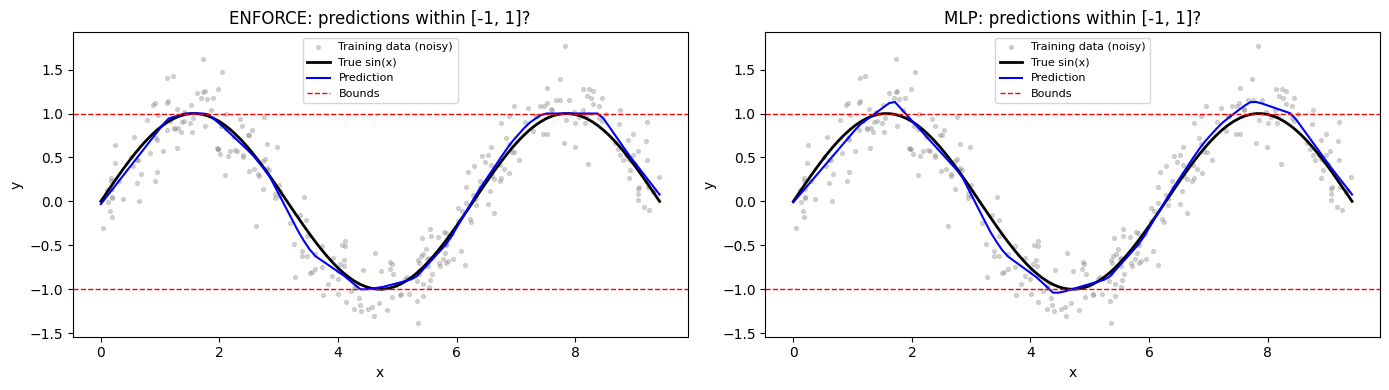

In [11]:
x_plot = x_test[:, 0]
sort_idx = np.argsort(x_plot)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, preds, title in zip(axes, [preds_e, preds_m], ['ENFORCE', 'MLP']):
    ax.scatter(x_train[:, 0], y_train[:, 0], s=8, alpha=0.3,
               color='grey', label='Training data (noisy)')
    ax.plot(x_plot[sort_idx], np.sin(x_plot[sort_idx]),
            'k-', linewidth=2, label='True sin(x)')
    ax.plot(x_plot[sort_idx], preds[sort_idx, 0],
            'b-', linewidth=1.5, label='Prediction')
    ax.axhline( 1.0, color='r', linestyle='--', linewidth=1, label='Bounds')
    ax.axhline(-1.0, color='r', linestyle='--', linewidth=1)
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.legend(fontsize=8)
    ax.set_title(f'{title}: predictions within [-1, 1]?')

plt.tight_layout()
plt.show()

## Summary

The Fischer-Burmeister reformulation converts inequality constraints into
equalities, letting ENFORCE enforce them without any change to the core
Newton-projection algorithm.

### Key API recap — inequalities

```python
from src.enforce.fb_inequality_constraints import FischerBurmeisterReformulation

# 1. Define inequalities g_i(x, y) <= 0
def g_upper(x, y): return y[:, 0] - 1.0   # y <= 1
def g_lower(x, y): return -y[:, 0] - 1.0  # y >= -1

# 2. Create the FB wrapper
fb = FischerBurmeisterReformulation(
    n_original_outputs=1, inequalities=[g_upper, g_lower]
)

# 3. Extend training labels with zero λ columns
y_train_ext = fb.extend_outputs(y_train)  # [N, 1] -> [N, 3]

# 4. Scale (extended data, safe std for zero-std columns)
x_tr_s, y_tr_s, x_te_s, y_te_s, sp = scale_data(x_train, y_train_ext, ...)

# 5. Build model  (output_neurons = fb.no, not fb.no + fb.n_ineq)
cfg   = ENFORCEConfig(output_neurons=fb.no, ada_np_auto_activation=False, ...)
model = ENFORCE(c=fb, fb=fb, config=cfg, constrained=True, weighting_option=1)

# 6. Train / Evaluate as normal
model = Trainer(model, TrainingConfig(epochs=500)).fit(x_tr_t, y_tr_t)
result = Evaluator(model, EvaluationConfig(
    n_original_outputs=fb.no, inequalities=fb.inequalities
)).evaluate(x_te_t, y_te_t, sp)

# 7. Extract original outputs (discard λ columns)
predictions = fb.extract_outputs(result.predictions)  # [N, fb.no]
```